<a href="https://colab.research.google.com/github/Ronconi58/Bigdata-Projeto/blob/main/C%C3%B3pia_de_Projeto_Big_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho de big data em python


Sessão Spark iniciada com sucesso!

Arquivos carregados diretamente do GitHub com sucesso!

=== LIMPEZA DOS DADOS ===

=== REMOÇÃO DE DUPLICADOS ===
Registros antes da remoção:
Base órgão: 88514
Base pessoa: 284128

Registros após remoção:
Base órgão: 88514
Base pessoa: 284124

=== VALORES NULOS ===

Base órgão:
ANOMES               0
DESC_INF             0
DESC_ORG_AUTUADOR    0
DESCR_MUNIC_INF      0
LIT_PTO              0
TIPO                 0
AIT                  0
dtype: int64

Base pessoa:
ANOMES             0
DESC_INF           0
SEXO_ARQ           0
FAIXA              0
DESCR_MUNIC_INF    0
LIT_PTO            0
TIPO               0
AIT                0
dtype: int64

=== PADRONIZAÇÃO DE TEXTO ===
Textos padronizados com sucesso!

Valores válidos em SEXO_ARQ:
['M' 'F']

=== EXEMPLO COM PYSPARK ===

Primeiras 5 linhas:
+------+--------------------+--------+---------------+------------------+----------+--------+---+
|ANOMES|            DESC_INF|SEXO_ARQ|          FAIXA|   DESCR_MU

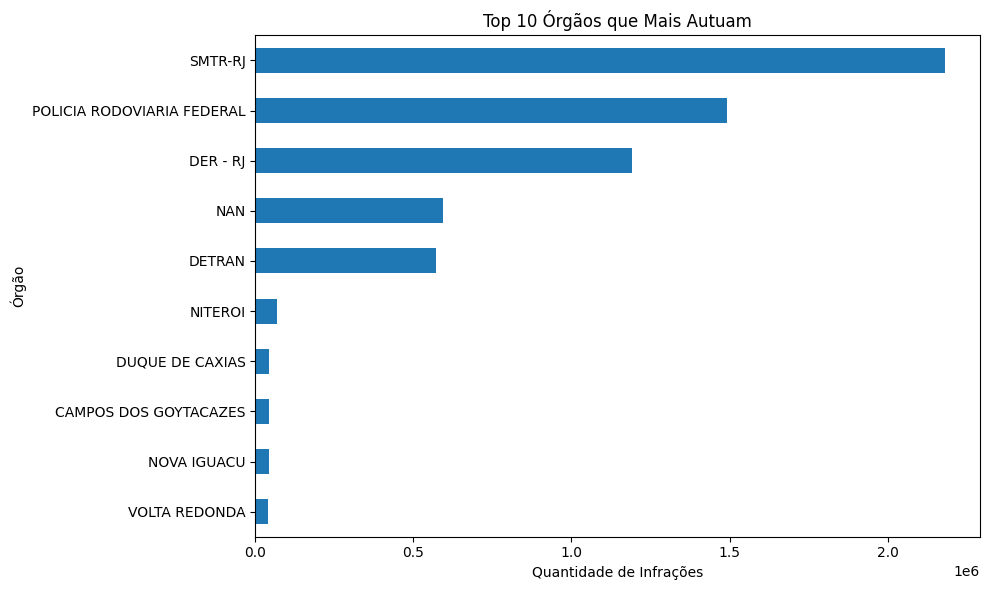


=== INFRAÇÕES POR SEXO ===
SEXO_ARQ
M    3204998
F    1162176
Name: AIT, dtype: int64


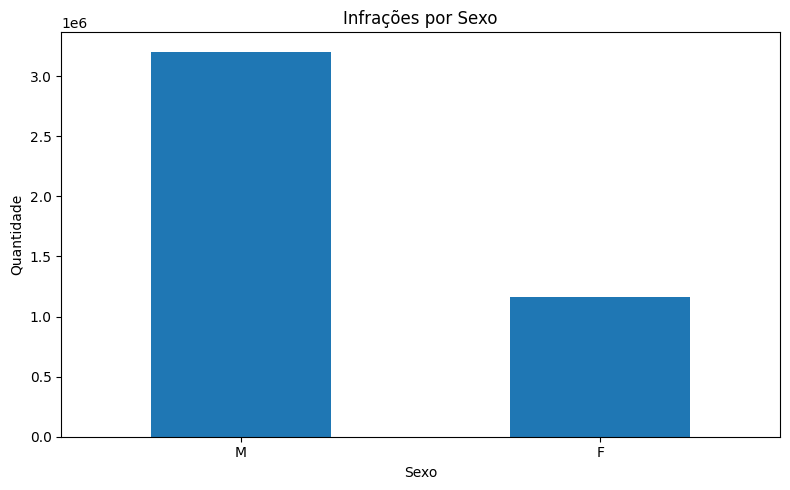


=== INFRAÇÕES POR FAIXA ETÁRIA ===
FAIXA
DE 18 A 30 ANOS      525310
DE 31 A 40 ANOS      956907
DE 41 A 50 ANOS     1113405
DE 51 A 60 ANOS      839002
ACIMA DE 60 ANOS     932550
Name: AIT, dtype: int64


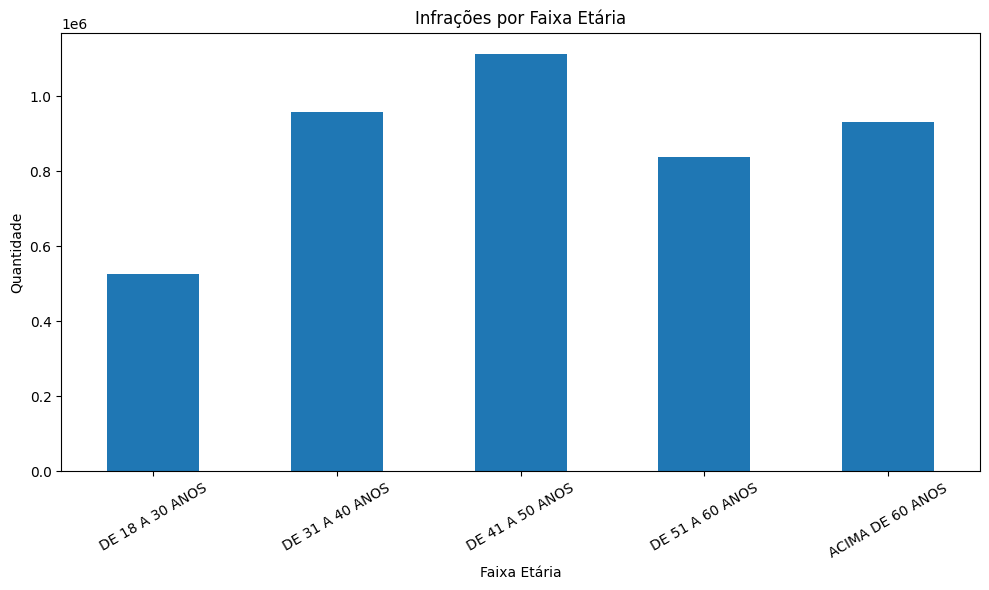


=== DISTRIBUIÇÃO DE FREQUÊNCIA ===
                  Frequência Absoluta  Frequência Relativa (%)
FAIXA                                                         
DE 41 A 50 ANOS                 52503                    22.70
DE 31 A 40 ANOS                 51670                    22.34
DE 18 A 30 ANOS                 44345                    19.17
DE 51 A 60 ANOS                 42832                    18.52
ACIMA DE 60 ANOS                39984                    17.28


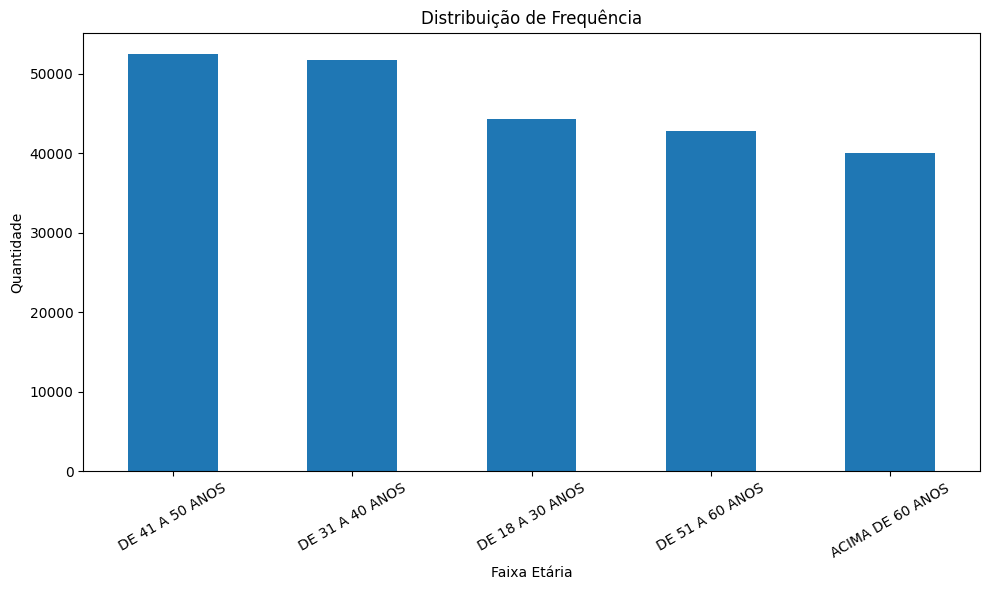


=== DETECÇÃO DE OUTLIERS ===
Quantidade de outliers:
34668

Exemplo de outliers:
     ANOMES                                 DESC_INF SEXO_ARQ  \
155  202401  DIRIGIR VEICULO SEM POSSUIR CNH/PPD/ACC        M   
160  202401  DIRIGIR VEICULO SEM POSSUIR CNH/PPD/ACC        M   
169  202401  DIRIGIR VEICULO SEM POSSUIR CNH/PPD/ACC        M   
171  202401  DIRIGIR VEICULO SEM POSSUIR CNH/PPD/ACC        M   
175  202401  DIRIGIR VEICULO SEM POSSUIR CNH/PPD/ACC        M   

               FAIXA        DESCR_MUNIC_INF     LIT_PTO            TIPO  AIT  
155  DE 18 A 30 ANOS           BELFORD ROXO  GRAVISSIMA        PALM TOP   10  
160  DE 18 A 30 ANOS         ANGRA DOS REIS  GRAVISSIMA        PALM TOP   12  
169  DE 18 A 30 ANOS              CABO FRIO  GRAVISSIMA        PALM TOP   19  
171  DE 18 A 30 ANOS  CAMPOS DOS GOYTACAZES  GRAVISSIMA        PALM TOP   15  
175  DE 18 A 30 ANOS        DUQUE DE CAXIAS  GRAVISSIMA  NÃO INFORMADO   10  


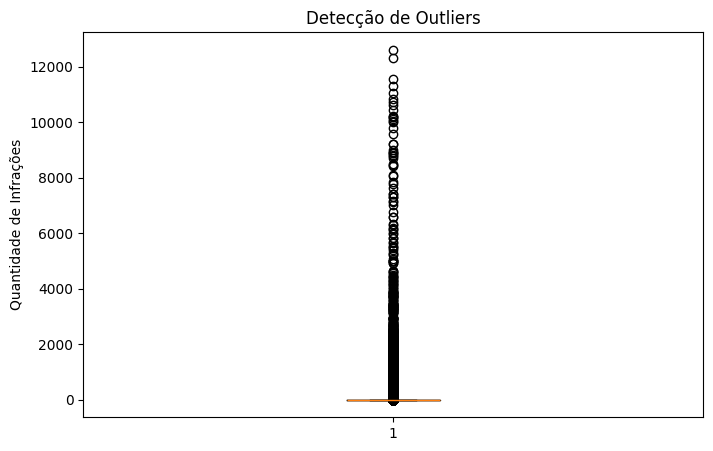


=== SEXO X FAIXA ETÁRIA ===
SEXO_ARQ               F       M
FAIXA                           
DE 18 A 30 ANOS   106467  418843
DE 31 A 40 ANOS   263175  693732
DE 41 A 50 ANOS   321703  791702
DE 51 A 60 ANOS   237874  601128
ACIMA DE 60 ANOS  232957  699593


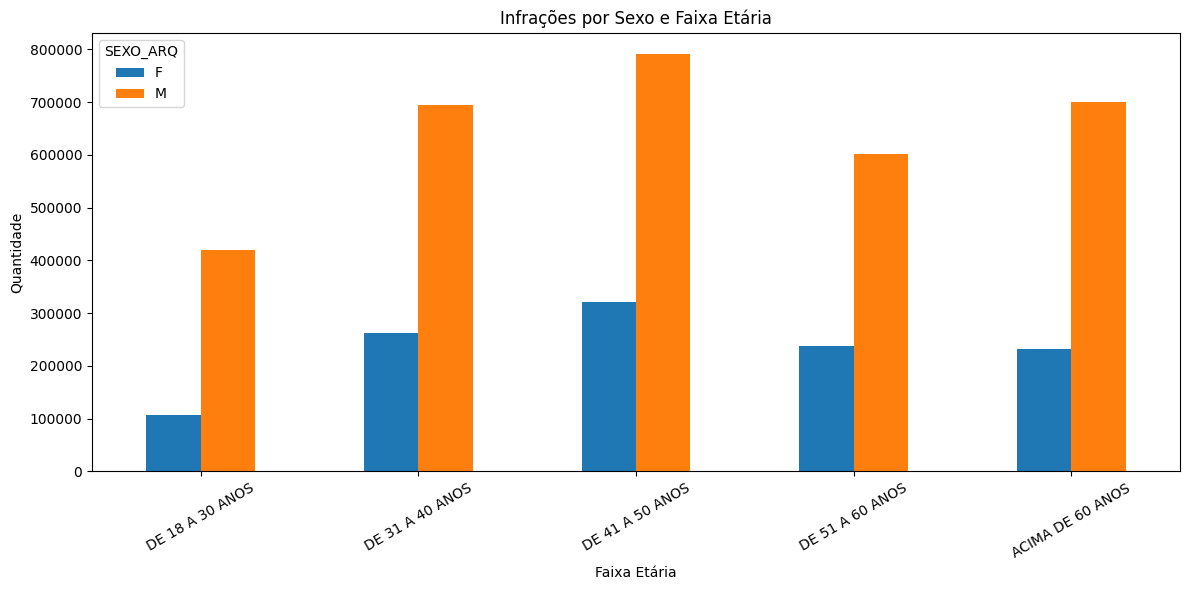


=== REGRESSÃO LINEAR ===
Coeficiente angular: 7027.166410453498
Intercepto: 558617.7448116833
R²: 0.269901408113982


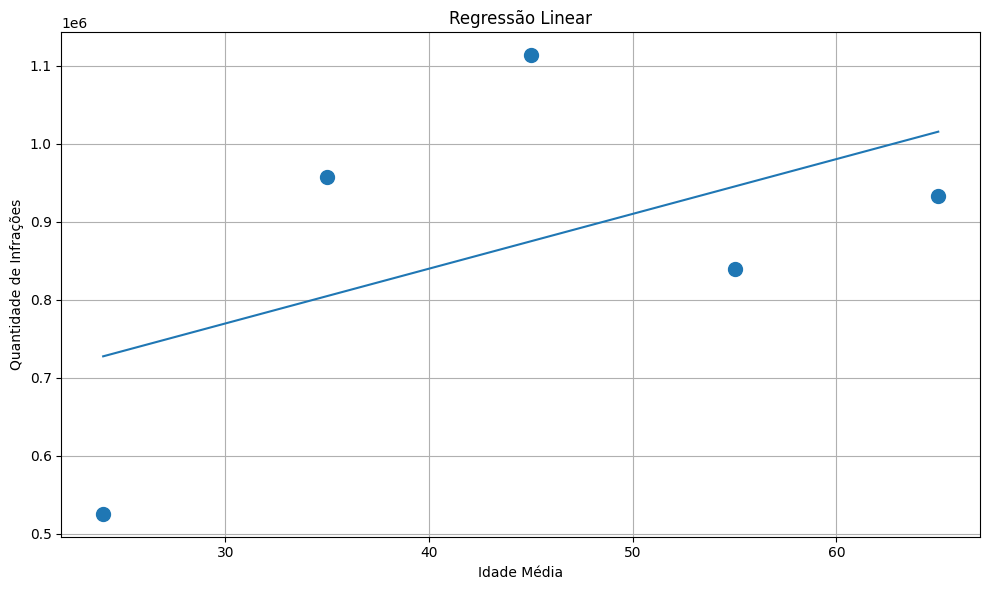


=== PERCENTUAL POR SEXO ===
SEXO_ARQ
M    73.39%
F    26.61%
Name: AIT, dtype: object

=== PERCENTUAL POR FAIXA ETÁRIA ===
FAIXA
DE 18 A 30 ANOS     12.03%
DE 31 A 40 ANOS     21.91%
DE 41 A 50 ANOS     25.49%
DE 51 A 60 ANOS     19.21%
ACIMA DE 60 ANOS    21.35%
Name: AIT, dtype: object

=== INSIGHTS PRINCIPAIS ===
Sexo com mais infrações: M
Faixa etária com mais infrações: DE 41 A 50 ANOS
Órgão que mais autua: SMTR-RJ
A regressão indica aumento nas infrações conforme a idade.

Projeto finalizado com sucesso!


In [ ]:
# PROJETO BIG DATA - ANÁLISE DE INFRAÇÕES DE TRÂNSITO

# Instalação das bibliotecas (Google Colab)
!pip install pandas matplotlib numpy scikit-learn pyspark -q

# IMPORTAÇÃO DAS BIBLIOTECAS

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from pyspark.sql import SparkSession
import warnings

warnings.filterwarnings("ignore")

# 2. INICIALIZAÇÃO DO PYSPARK

spark = (
    SparkSession.builder
    .appName("Analise_Infracoes_Transito")
    .getOrCreate()
)

print("Sessão Spark iniciada com sucesso!")

# LINKS DOS DADOS NO GITHUB

url_pessoa = "https://raw.githubusercontent.com/Ronconi58/Bigdata-Projeto/main/2.1-infracoes-por-sexo_idade-24%20(1).csv"

url_orgao = "https://raw.githubusercontent.com/Ronconi58/Bigdata-Projeto/main/2.5-infracoes-por-orgaoautuador-24%20(2).csv"

# LEITURA DOS DADOS

df_orgao = pd.read_csv(
    url_orgao,
    sep=";",
    encoding="latin1",
    engine="python"
)

df_pessoa = pd.read_csv(
    url_pessoa,
    sep=";",
    encoding="latin1",
    engine="python"
)

print("\nArquivos carregados diretamente do GitHub com sucesso!")

# LIMPEZA E TRATAMENTO DOS DADOS

print("\n=== LIMPEZA DOS DADOS ===")

# Corrige nomes das colunas
df_orgao.columns = (
    df_orgao.columns
    .str.replace("ï»¿", "", regex=False)
    .str.strip()
)

df_pessoa.columns = (
    df_pessoa.columns
    .str.replace("ï»¿", "", regex=False)
    .str.strip()
)

# Conversão da coluna AIT para número
df_orgao["AIT"] = pd.to_numeric(
    df_orgao["AIT"],
    errors="coerce"
).fillna(0)

df_pessoa["AIT"] = pd.to_numeric(
    df_pessoa["AIT"],
    errors="coerce"
).fillna(0)

# Remove espaços extras
for col in df_orgao.columns:
    if df_orgao[col].dtype == "object":
        df_orgao[col] = df_orgao[col].astype(str).str.strip()

for col in df_pessoa.columns:
    if df_pessoa[col].dtype == "object":
        df_pessoa[col] = df_pessoa[col].astype(str).str.strip()

# REMOÇÃO DE DUPLICADOS

print("\n=== REMOÇÃO DE DUPLICADOS ===")

print("Registros antes da remoção:")
print("Base órgão:", df_orgao.shape[0])
print("Base pessoa:", df_pessoa.shape[0])

df_orgao = df_orgao.drop_duplicates()
df_pessoa = df_pessoa.drop_duplicates()

print("\nRegistros após remoção:")
print("Base órgão:", df_orgao.shape[0])
print("Base pessoa:", df_pessoa.shape[0])

# VERIFICAÇÃO DE VALORES NULOS

print("\n=== VALORES NULOS ===")

print("\nBase órgão:")
print(df_orgao.isnull().sum())

print("\nBase pessoa:")
print(df_pessoa.isnull().sum())

# PADRONIZAÇÃO DOS TEXTOS

print("\n=== PADRONIZAÇÃO DE TEXTO ===")

for col in df_orgao.columns:
    if df_orgao[col].dtype == "object":
        df_orgao[col] = (
            df_orgao[col]
            .str.upper()
            .str.strip()
        )

for col in df_pessoa.columns:
    if df_pessoa[col].dtype == "object":
        df_pessoa[col] = (
            df_pessoa[col]
            .str.upper()
            .str.strip()
        )

print("Textos padronizados com sucesso!")

# LIMPEZA DA COLUNA SEXO

df_pessoa = df_pessoa[
    (df_pessoa["SEXO_ARQ"].notna()) &
    (~df_pessoa["SEXO_ARQ"].isin(["0", 0, ""])) &
    (df_pessoa["SEXO_ARQ"].isin(["M", "F"]))
]

print("\nValores válidos em SEXO_ARQ:")
print(df_pessoa["SEXO_ARQ"].unique())

# EXEMPLO PYSPARK

print("\n=== EXEMPLO COM PYSPARK ===")

# Converte Pandas para Spark
df_spark = spark.createDataFrame(df_pessoa)

# Primeiras linhas
print("\nPrimeiras 5 linhas:")
df_spark.show(5)

# Estrutura da base
print("\nEstrutura da base:")
df_spark.printSchema()

# Quantidade de registros
print("\nQuantidade de registros:")
print(df_spark.count())

# Seleciona colunas
print("\nSelecionando colunas:")
df_spark.select(
    "SEXO_ARQ",
    "FAIXA",
    "AIT"
).show(10)

# Agrupamento por sexo
print("\nAgrupamento por sexo:")
df_spark.groupBy(
    "SEXO_ARQ"
).sum(
    "AIT"
).show()

# Agrupamento por faixa etária
print("\nAgrupamento por faixa etária:")
df_spark.groupBy(
    "FAIXA"
).sum(
    "AIT"
).show()

# SQL no PySpark
df_spark.createOrReplaceTempView("infracoes")

print("\nConsulta SQL no PySpark:")

spark.sql("""
SELECT
    SEXO_ARQ,
    FAIXA,
    SUM(AIT) AS TOTAL_INFRACOES
FROM infracoes
GROUP BY SEXO_ARQ, FAIXA
ORDER BY TOTAL_INFRACOES DESC
""").show()

# VOLUME DE DADOS

print("\n=== VOLUME DE DADOS ===")

print(
    f"Base órgão: {df_orgao.shape[0]} registros"
)

print(
    f"Base pessoa: {df_pessoa.shape[0]} registros"
)

# ANÁLISE POR ÓRGÃO AUTUADOR

top_orgaos = (
    df_orgao
    .groupby("DESC_ORG_AUTUADOR")["AIT"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\n=== TOP 10 ÓRGÃOS ===")
print(top_orgaos)

plt.figure(figsize=(10,6))

top_orgaos.sort_values().plot(kind="barh")

plt.title("Top 10 Órgãos que Mais Autuam")
plt.xlabel("Quantidade de Infrações")
plt.ylabel("Órgão")

plt.tight_layout()
plt.show()

# ANÁLISE POR SEXO

infracoes_por_sexo = (
    df_pessoa
    .groupby("SEXO_ARQ")["AIT"]
    .sum()
    .sort_values(ascending=False)
)

print("\n=== INFRAÇÕES POR SEXO ===")
print(infracoes_por_sexo)

plt.figure(figsize=(8,5))

infracoes_por_sexo.plot(kind="bar")

plt.title("Infrações por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Quantidade")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# ANÁLISE POR FAIXA ETÁRIA

ordem_faixas = [
    "DE 18 A 30 ANOS",
    "DE 31 A 40 ANOS",
    "DE 41 A 50 ANOS",
    "DE 51 A 60 ANOS",
    "ACIMA DE 60 ANOS"
]

infracoes_por_faixa = (
    df_pessoa
    .groupby("FAIXA")["AIT"]
    .sum()
    .reindex(ordem_faixas)
    .dropna()
)

print("\n=== INFRAÇÕES POR FAIXA ETÁRIA ===")
print(infracoes_por_faixa)

plt.figure(figsize=(10,6))

infracoes_por_faixa.plot(kind="bar")

plt.title("Infrações por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Quantidade")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# DISTRIBUIÇÃO DE FREQUÊNCIA

print("\n=== DISTRIBUIÇÃO DE FREQUÊNCIA ===")

freq_abs = df_pessoa["FAIXA"].value_counts()

freq_rel = (
    df_pessoa["FAIXA"]
    .value_counts(normalize=True) * 100
)

distribuicao = pd.DataFrame({
    "Frequência Absoluta": freq_abs,
    "Frequência Relativa (%)": freq_rel.round(2)
})

print(distribuicao)

plt.figure(figsize=(10,6))

freq_abs.plot(kind="bar")

plt.title("Distribuição de Frequência")
plt.xlabel("Faixa Etária")
plt.ylabel("Quantidade")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# DETECÇÃO DE OUTLIERS

print("\n=== DETECÇÃO DE OUTLIERS ===")

Q1 = df_pessoa["AIT"].quantile(0.25)
Q3 = df_pessoa["AIT"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_pessoa[
    (df_pessoa["AIT"] < limite_inferior) |
    (df_pessoa["AIT"] > limite_superior)
]

print("Quantidade de outliers:")
print(outliers.shape[0])

print("\nExemplo de outliers:")
print(outliers.head())

plt.figure(figsize=(8,5))

plt.boxplot(df_pessoa["AIT"])

plt.title("Detecção de Outliers")
plt.ylabel("Quantidade de Infrações")

plt.show()

# CRUZAMENTO SEXO X FAIXA ETÁRIA

sexo_faixa = df_pessoa.pivot_table(
    values="AIT",
    index="FAIXA",
    columns="SEXO_ARQ",
    aggfunc="sum",
    fill_value=0
)

sexo_faixa = (
    sexo_faixa
    .reindex(ordem_faixas)
    .dropna(how="all")
)

print("\n=== SEXO X FAIXA ETÁRIA ===")
print(sexo_faixa)

sexo_faixa.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Infrações por Sexo e Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Quantidade")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# REGRESSÃO LINEAR

mapa_idade = {
    "DE 18 A 30 ANOS": 24,
    "DE 31 A 40 ANOS": 35,
    "DE 41 A 50 ANOS": 45,
    "DE 51 A 60 ANOS": 55,
    "ACIMA DE 60 ANOS": 65
}

df_reg = df_pessoa.copy()

df_reg["IDADE_MEDIA"] = (
    df_reg["FAIXA"]
    .map(mapa_idade)
)

df_reg = df_reg.dropna(subset=["IDADE_MEDIA"])

dados_reg = (
    df_reg
    .groupby("IDADE_MEDIA")["AIT"]
    .sum()
    .reset_index()
)

X = dados_reg["IDADE_MEDIA"].values.reshape(-1,1)
y = dados_reg["AIT"].values

modelo = LinearRegression()

modelo.fit(X, y)

y_pred = modelo.predict(X)

print("\n=== REGRESSÃO LINEAR ===")

print("Coeficiente angular:", modelo.coef_[0])
print("Intercepto:", modelo.intercept_)
print("R²:", modelo.score(X, y))

plt.figure(figsize=(10,6))

plt.scatter(X, y, s=100)

plt.plot(X, y_pred)

plt.title("Regressão Linear")
plt.xlabel("Idade Média")
plt.ylabel("Quantidade de Infrações")

plt.grid(True)

plt.tight_layout()
plt.show()

# PERCENTUAIS

percentual_sexo = (
    infracoes_por_sexo /
    infracoes_por_sexo.sum()
) * 100

percentual_faixa = (
    infracoes_por_faixa /
    infracoes_por_faixa.sum()
) * 100

print("\n=== PERCENTUAL POR SEXO ===")
print(percentual_sexo.round(2).astype(str) + "%")

print("\n=== PERCENTUAL POR FAIXA ETÁRIA ===")
print(percentual_faixa.round(2).astype(str) + "%")

# 16. INSIGHTS FINAIS

print("\n=== INSIGHTS PRINCIPAIS ===")

print(
    "Sexo com mais infrações:",
    infracoes_por_sexo.idxmax()
)

print(
    "Faixa etária com mais infrações:",
    infracoes_por_faixa.idxmax()
)

print(
    "Órgão que mais autua:",
    top_orgaos.idxmax()
)

if modelo.coef_[0] > 0:
    print(
        "A regressão indica aumento nas infrações conforme a idade."
    )
else:
    print(
        "A regressão indica redução nas infrações conforme a idade."
    )

print("\nProjeto finalizado com sucesso!")